# HuffPost News Category Classification — Final Project Notebook

**Project Team:** Ruth Tolulope Faseun, Tyler Brantingham, Liam Kapples  
**Course:** DX 799 — Applied Machine Learning · Spring 2026  
**Due Date:** April 27, 2026  
**Purpose:** End-to-end implementation of the final DistilBERT classification pipeline for 34-class HuffPost news category prediction, building on experiments conducted in Milestones 1 and 2.  

> **Note:** This notebook was developed and tested on Google Colab (T4 GPU, PyTorch backend). TF Transformers classes were incompatible with the Colab/VS Code environment; the DistilBERT section uses PyTorch. All other models use TensorFlow/Keras.

---
# A.1: Setup and Context

This section summarizes the work completed in Milestones 1 and 2, and presents the complete final preprocessing pipeline used throughout this notebook.

## A.1.1: Milestone 1 — EDA & Problem Framing

### Dataset
The HuffPost News Category dataset contains **200,853 news articles** across **41 categories** with fields: `headline`, `short_description`, `category`, `authors`, `link`, `date`. The team selected this dataset over image classification alternatives due to its real-world NLP applicability.

### Key EDA Findings

**Class imbalance (32× ratio):**
| Category | Count |
|---|---|
| POLITICS (largest) | 32,739 |
| WELLNESS | 17,827 |
| ENTERTAINMENT | 16,058 |
| EDUCATION (smallest) | 1,004 |

**Text length statistics:**
- Headline: mean 9.5 words (std 3.1), range 0–44 words
- Description: mean 19.7 words (std 14.4), range 0–243 words
- Combined (p50 / p95 / p99): 29 / 56 / 68 words → max_length=128 truncates only ~0.1% of samples

**Data quality issues:**
- 6 empty headlines (dropped)
- 19,712 articles (~9.8%) missing `short_description` → used headline-only text
- 1,398 duplicate (headline, category) pairs
- 717 headlines appearing under multiple categories (genuine label ambiguity)

**Category overlap identified (root cause of model confusion):**
```
ARTS & CULTURE  ↔  ARTS  ↔  CULTURE & ARTS
STYLE           ↔  STYLE & BEAUTY
HEALTHY LIVING  ↔  WELLNESS
THE WORLDPOST   ↔  WORLDPOST
PARENTS         ↔  PARENTING
TASTE           ↔  FOOD & DRINK
```

### Preprocessing Pipeline

```python
# 1. Text construction
text = headline.lower() + " [sep] " + short_description.lower()

# 2. Drop near-empty samples
df = df[df['text'].str.len() > 5]

# 3. Stratified 80/10/10 split
train_test_split(..., stratify=labels)

# 4. Class weights (balanced) to address 32× imbalance
compute_class_weight("balanced", classes=np.arange(41), y=train_labels)
# Weight range: 0.150× (POLITICS) – 4.874× (EDUCATION)

# 5. Tokenization
TextVectorization(max_tokens=20000, output_sequence_length=128)
```

### Feature Engineering Decisions

- **Vocabulary cap at 20,000 tokens** — sufficient for news domain; larger vocab didn't improve results
- **Sequence length 128** — preserves 99%+ of samples; no meaningful truncation loss
- **`[sep]` separator token** — concatenates headline and description into single input sequence
- **t-SNE / PCA visualizations** — confirmed no linear separation between categories; overlap validated the need for deep architectures
- **GloVe 100d identified as promising** — EDA showed word frequency alone insufficient to distinguish overlapping categories; pretrained semantic vectors expected to help

### Primary Success Metric: Macro-F1

Accuracy is misleading on a 32× imbalanced 41-class dataset. Macro-F1 treats all classes equally — a model that ignores minority classes (e.g. EDUCATION, GOOD NEWS) is penalized regardless of overall accuracy.


## A.1.2: Milestone 2 — Model Experiments & Key Learnings

### Experiment Summary

Three models were trained on the 41-class dataset. Results from these experiments directly informed the optimal model design.

| Model | Architecture | Test Acc | Macro-F1 | Train Time | Key Decision |
|---|---|---|---|---|---|
| Baseline | Embedding(20k,64) → GAP → Dense(64) → Dense(41) | 0.5832 | — | 4.75 min | Bag-of-words ceiling |
| Custom (BiLSTM) | GloVe(100d, trainable) → BiLSTM(64) → Dense(64) → Dense(41) | 0.6433 | — | 121.7 min | **Pretrained embeddings decisive** |
| DistilBERT | Frozen base → GAP → Dropout(0.3) → Dense(41) (two-phase in TCB) | 0.6457 | 0.5824 | 135.2 min | **Full fine-tuning essential** |

### What Each Experiment Revealed

**Baseline (Embedding + GlobalAveragePooling):**
```python
Embedding(20000, 64) → GlobalAveragePooling1D → Dense(64, relu) → Dense(41, softmax)
# Result: test_acc=0.5832, best_epoch=14, train_time=4.75 min
```
- GAP discards word order — treats each document as a bag of tokens
- Overfitting after epoch 14; early stopping at epoch 19
- Establishes the ceiling for order-insensitive models: ~58% accuracy
- **Learning:** Ordering matters for distinguishing overlapping news categories

**Custom Model (GloVe + BiLSTM):**
```python
Embedding(20000, 100, weights=[glove_matrix], trainable=True)
  → Bidirectional(LSTM(64)) → Dropout(0.3) → Dense(64, relu) → Dropout(0.2) → Dense(41, softmax)
# Result: test_acc=0.6433, best_epoch=4, train_time=121.7 min
```
Three variants were tested before settling on the best:

| Variant | Setup | Test Acc |
|---|---|---|
| V1 | GloVe frozen → GAP → Dense(64) | 0.5289 |
| V2 | GloVe frozen → Dropout(0.4) → GAP → Dense(64) | 0.4550 |
| **V3 (best)** | **GloVe trainable → BiLSTM(64) → Dropout(0.3) → Dense(64) → Dense(41)** | **0.6433** |

- Pretrained GloVe embeddings gave +6.2% over baseline — the single highest-leverage decision at this tier
- **Trainable embeddings essential:** frozen embeddings (V1) underperformed; V2 showed aggressive dropout (0.4) on frozen embeddings actively hurts
- **BiLSTM captures word order** — critical for distinguishing `POLITICS` from `WORLD NEWS`, `WELLNESS` from `HEALTHY LIVING`
- Converged at epoch 4 (fast); val_loss and val_accuracy largely agreed at this model tier

**DistilBERT Fine-tuning:**

The next iteration used two-phase fine-tuning:
```python
# Phase 1: frozen base, train head only
distilbert_base.trainable = False
model.compile(optimizer=Adam(1e-3), ...)   # head: GAP → Dropout(0.3) → Dense(41)
# Phase 2: full fine-tune at controlled LR
distilbert_base.trainable = True
model.compile(optimizer=Adam(2e-5), ...)
# Result: test_acc=0.6457, macro-F1=0.5824, train_time=135.2 min
```

Next experiment used frozen base only → test_acc=0.6017 (–4.4%). DistilBERT still improving at epoch 10 when stopped — not converged.

**Critical observation — val_loss vs val_accuracy divergence:**
- On the 41-class imbalanced dataset, `val_loss` bottomed out at epoch 2 for the BiLSTM
- `val_accuracy` kept improving until epoch 6
- Monitoring `val_loss` for early stopping prematurely stops training
- **Fix in optimal model: monitor `val_accuracy`, not `val_loss`**

### Per-Class F1 (DistilBERT, 41 classes)

Hardest categories (F1 < 0.40):
```
GOOD NEWS   0.352    IMPACT      0.371    EDUCATION   0.383
```
Easiest categories (F1 > 0.85):
```
STYLE & BEAUTY  0.868    WEDDINGS  0.859    SPORTS  0.844
```

Hardest categories are either minority classes or have ambiguous/overlapping content. This directly motivated the label consolidation (41 → 35) in this notebook.

### Three Improvements Implemented in This Notebook

1. **Label consolidation 41 → 35** — merges the 7 near-synonymous category pairs identified in EDA; removes systematic confusion at the data level
2. **`val_accuracy` early stopping** — replaces `val_loss` monitoring to avoid premature convergence
3. **Warmup + cosine decay LR schedule (Phase 2)** — replaces flat `lr=2e-5`; linear warmup prevents large early gradient updates on the unfrozen base, cosine decay provides smooth annealing


## A.1.3: Final Preprocessing Pipeline

The pipeline below implements all finalized data loading, cleaning, feature engineering, and splitting steps. Key decisions:

**Data Loading and Cleaning:** The HuffPost dataset was loaded from HuggingFace using `load_dataset`. Cleaning steps included stripping whitespace, dropping 6 empty headlines, filling 19,707 empty descriptions with empty strings, lowercasing all text, and removing 491 duplicate entries — leaving 200,356 rows.

**Preprocessing and Standardization:** Headlines and short descriptions were concatenated with a `[SEP]` separator token into a single input sequence. Lowercase normalization ensures GloVe token compatibility (e.g., "Growth" and "growth" map to the same vector). `TextVectorization` was set to 20,000 vocabulary tokens and 128 sequence length — chosen based on the 95th percentile of combined text length from Milestone 1 EDA, ensuring less than 0.1% of samples are truncated.

**Label Consolidation:** 41 original categories were merged to 34 consolidated classes, resolving 7 near-synonymous category pairs identified in EDA (e.g., ARTS & CULTURE ↔ ARTS, WORLDPOST ↔ THE WORLDPOST). This directly addresses the label ambiguity that caused systematic confusion in Milestone 2 models.

**Train / Validation / Test Splits:** Stratified 80/10/10 split using `random_state=42`, ensuring each subset maintains the same class distribution as the full dataset. This is critical given the 32× imbalance ratio. Final sizes: 160,284 / 20,036 / 20,036.

**Class Imbalance Handling:** `compute_class_weight('balanced')` was applied to the training set to prevent the majority classes (POLITICS: 32,739) from dominating gradient updates over minority classes (EDUCATION: 1,004).

In [2]:
# Install required packages for this notebook
!pip install torch transformers datasets scikit-learn spacy tqdm pandas numpy matplotlib -q
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 15.4 MB/s  0:00:00m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [3]:
# ── Imports: standard libraries, data science, NLP ──────────────────────────
import os, time, math, random
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm import tqdm
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.utils.class_weight import compute_class_weight

from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

# Reproducibility
random.seed(42)
np.random.seed(42)

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

print("Imports loaded.")


Imports loaded.


In [4]:
# Download and load the HuffPost dataset from HuggingFace (progress bars suppressed)
import urllib.request
from datasets import disable_progress_bar
disable_progress_bar()

# download directly
urllib.request.urlretrieve(
    "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json",
    "huffpost.json"
)

# load from local file
huff_all = load_dataset("json", data_files="huffpost.json", split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))


Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


In [50]:
# Display one raw example to verify dataset loaded correctly
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


In [51]:
# Build DataFrame from HuggingFace dataset and inspect its shape and contents
df = pd.DataFrame({
    "category":          huff_all["category"],
    "headline":          huff_all["headline"],
    "short_description": huff_all["short_description"],
    "authors":           huff_all["authors"],
    "date":              huff_all["date"]
})

print(df.shape)
df.head()

(200853, 5)


,category,headline,short_description,authors,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,She left her husband. He killed their children...,Melissa Jeltsen,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Of course it has a song.,Andy McDonald,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,The actor and his longtime girlfriend Anna Ebe...,Ron Dicker,2018-05-26
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,The actor gives Dems an ass-kicking for not fi...,Ron Dicker,2018-05-26
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,"The ""Dietland"" actress said using the bags is ...",Ron Dicker,2018-05-26


In [52]:
# Strip whitespace, drop empty headlines, deduplicate, and build combined text column
# strip whitespace
df['headline'] = df['headline'].str.strip()
df['short_description'] = df['short_description'].str.strip()

# drop
df = df[df['headline'] != ""]

# replace empty samples with ""
df['short_description'] = df['short_description'].replace('', np.nan).fillna('')

empty_desc_count = (df['short_description'] == "").sum()
print(f"Rows after cleaning: {df.shape[0]}")
print(f"Rows with empty desc:    {empty_desc_count}")
df.head()

# concatenate & lowercase
df['text'] = (df['headline'] + " [SEP] " + df['short_description']).str.lower()

# check for dupes
num_dupes = df['text'].duplicated().sum()
print(f"Duplicate rows found: {num_dupes}")

# drop dupes
df = df.drop_duplicates(subset='text').reset_index(drop=True)

print(f"Rows after deduplication: {df.shape[0]}")
df[['category', 'text']].head()

Rows after cleaning: 200847
Rows with empty desc:    19707
Duplicate rows found: 491
Rows after deduplication: 200356


,category,text
0,CRIME,there were 2 mass shootings in texas last week...
1,ENTERTAINMENT,will smith joins diplo and nicky jam for the 2...
2,ENTERTAINMENT,hugh grant marries for the first time at age 5...
3,ENTERTAINMENT,jim carrey blasts 'castrato' adam schiff and d...
4,ENTERTAINMENT,julianna margulies uses donald trump poop bags...


In [53]:
# Merge overlapping categories (41 → 34) and encode labels as integers
# ══════════════════════════════════════════════════════════════════
# [ADDED] Label Merging: consolidate overlapping/ambiguous categories
# Reduces 41 → 34 classes by merging groups that share near-identical
# content — directly addresses the overlap found in error analysis.
# ══════════════════════════════════════════════════════════════════
MERGE_MAP = {
    "WORLDPOST":      "WORLD NEWS",     # same content, different label
    "THE WORLDPOST":  "WORLD NEWS",     # same content, different label
    "TASTE":          "FOOD & DRINK",   # subset of FOOD & DRINK
    "PARENTS":        "PARENTING",      # duplicate of PARENTING
    "ARTS":           "ARTS & CULTURE", # subset of ARTS & CULTURE
    "CULTURE & ARTS": "ARTS & CULTURE", # duplicate of ARTS & CULTURE
    "STYLE":          "STYLE & BEAUTY", # subset of STYLE & BEAUTY
}
df['category'] = df['category'].replace(MERGE_MAP)
print(f"Categories after merging: {df['category'].nunique()} (was 41)")
print(sorted(df['category'].unique()))


# get unique categories and sort
unique_categories = sorted(df['category'].unique())

# encode category column
df['category'] = pd.Categorical(df['category'], categories=unique_categories)

# assign integer codes new column
df['label'] = df['category'].cat.codes

print(f"Number of unique classes: {df['label'].nunique()}")
print("\n Sample label mapping (first 5):")
for i, cat in enumerate(unique_categories[:5]):
    print(f"  {i:2d} → {cat}")

# [ADDED] dynamic class count — updates automatically after label merging
NUM_CLASSES = df['label'].nunique()
print(f"NUM_CLASSES = {NUM_CLASSES}")

Categories after merging: 34 (was 41)
['ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK', 'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS', 'STYLE & BEAUTY', 'TECH', 'TRAVEL', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS']
Number of unique classes: 34

 Sample label mapping (first 5):
   0 → ARTS & CULTURE
   1 → BLACK VOICES
   2 → BUSINESS
   3 → COLLEGE
   4 → COMEDY
NUM_CLASSES = 34


In [54]:
# Stratified 80/10/10 train/val/test split — consistent seed across all models
texts  = df['text'].values
labels = df['label'].values

X_tr_raw, X_tmp_raw, y_tr, y_tmp = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels)
X_val_raw, X_test_raw, y_val_r, y_test_r = train_test_split(
    X_tmp_raw, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

print(f"Train: {len(X_tr_raw)} | Val: {len(X_val_raw)} | Test: {len(X_test_raw)}")


Train: 160284 | Val: 20036 | Test: 20036


---
# A.2: Model Selection and Retraining

Three model families were trained and evaluated in Milestone 2. **DistilBERT with partial unfreeze of the final two transformer layers** was selected as the final model based on validation performance, generalization gap, and computational feasibility.

## A.2.1: Final Architecture and Justification

**Architecture selected:** DistilBERT-base-uncased (HuggingFace) with partial fine-tuning — transformer layers 0–3 frozen (general language representations), layers 4–5 unfrozen (task-specific adaptation), plus a classification head.

**Why DistilBERT:** DistilBERT is a transformer-based model specifically designed for text classification. With 6 transformer layers and 66M parameters, it delivers 97% of full BERT performance at roughly half the compute cost. Contextual representations directly address the core weakness identified in Milestone 1 t-SNE analysis — overlapping categories that simple word-frequency models cannot separate.

**Why partial unfreeze:** A fully frozen base (Milestone 2 experiment) achieved only 0.6017 test accuracy — trainable embeddings are critical for adapting to HuffPost's task-specific vocabulary. Full fine-tuning of all 66M parameters at lr=2e-5 risks catastrophic forgetting and requires significantly more compute. Unfreezing only the last 2 transformer layers (14.8M trainable params) provides meaningful task adaptation while preserving the general language representations in layers 0–3.

**Progression that justified this choice:**

| Model | Test Acc | Key Limitation |
|---|---|---|
| Baseline (Embedding + GAP) | 0.5886 | No word order, no pretrained semantics |
| Custom (GloVe + BiLSTM) | 0.6433 | Limited context window, no deep attention |
| DistilBERT frozen (Milestone 2) | 0.6017 | Frozen base cannot adapt vocabulary |
| **DistilBERT partial unfreeze (this notebook)** | **0.7323** | — |


## A.2.2: Hyperparameter Definitions

All key hyperparameters are defined as named constants below for reproducibility and easy modification.

In [55]:
# ── Hyperparameter Constants ──────────────────────────────────────────────────
# Shared constants
RANDOM_SEED   = 42
NUM_CLASSES   = 34          # After label consolidation (41 → 34)
TEST_SPLIT    = 0.20        # 80/10/10 via two-stage stratified split
VAL_SPLIT     = 0.50        # of the 20% held-out

# Final model — DistilBERT with partial unfreeze
BERT_MAX_LEN       = 128
BERT_BATCH_SIZE    = 32
BERT_LR            = 2e-5   # Adam — stable for transformer fine-tuning
BERT_EPOCHS        = 10
BERT_PATIENCE      = 3      # Early stopping on val_loss
BERT_FROZEN_LAYERS = 4      # Freeze layers 0–3; unfreeze 4–5

print("Hyperparameters defined.")


Hyperparameters defined.


## A.2.3: Baseline Model — Embedding + Global Average Pooling

A simple embedding-based model establishes the performance floor. GlobalAveragePooling treats text as a bag of embeddings with no word order — this is intentional for a baseline.

**Baseline results:** Val accuracy at min loss = 0.5892, test accuracy = 0.5886 (gap = 0.0006, confirming good generalization). Training accuracy reached 0.749 before early stopping at epoch 19, restoring best weights from epoch 14. The 0.5892 validation accuracy sets the ceiling for order-insensitive models on this dataset and confirms the difficulty of distinguishing overlapping HuffPost categories without sequential context.

## A.2.4: Custom Model — GloVe + Bidirectional LSTM

Three variants were tested. The final configuration uses 100-dimensional trainable GloVe embeddings with a Bidirectional LSTM to capture word order — the key weakness of the baseline. Frozen embeddings (V1) and aggressive early dropout (V2) both underperformed; trainable embeddings with post-LSTM dropout (V3) gave the best result.

### Second Attempt: GloVe + BiLSTM + Dropout

The first version of experiment three crashed out ran for over an hour. Here is a leaner version that should run without bottleneck.

**Custom model results:** Val accuracy at min loss = 0.6512 at epoch 4, test accuracy = 0.6433 (gap = 0.0008). Early stopping at epoch 9. The +6.2% improvement over baseline confirms that pretrained GloVe embeddings and BiLSTM sequential processing are both essential — frozen embeddings and overly aggressive dropout (0.4) both hurt performance. Trainable embeddings are critical for HuffPost's task-specific vocabulary adaptation. BiLSTM captures word order that GlobalAveragePooling cannot, particularly important for distinguishing categories like POLITICS vs. WORLD NEWS.
Key insight: more dropout is not always better — it must match model capacity. The BiLSTM has the best accuracy/compute tradeoff of the three models, achieving 0.6433 in approximately 2 hours.

## A.2.5: Final Model — DistilBERT with Partial Unfreeze

DistilBERT-base-uncased is loaded from HuggingFace with transformer layers 0–3 frozen and layers 4–5 unfrozen. This yields **14,792,482 trainable parameters** — enough for meaningful task adaptation without the compute cost of full fine-tuning. Adam optimizer at lr=2e-5 is standard for transformer fine-tuning; patience=3 on validation loss prevents overfitting during the PyTorch training loop.

**Fine-tuning strategy rationale:** Full fine-tuning (all 66M params) on a Colab T4 GPU would require 6–8+ hours with uncertain marginal gain. Partial unfreeze of the final two layers — which encode the most task-specific representations — provides meaningful adaptation in ~25 minutes.

In [56]:
# Initialize results dictionary with hardcoded Milestone 2 values for visualization
# format_hms and print_results are utility helpers used throughout this section

results = {}
parameter_settings = {}

def print_results():
    """Print all logged model results sorted by validation accuracy."""
    for title, (acc, ep) in sorted(results.items(),
                                   key=lambda kv: kv[1][0],
                                   reverse=True):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

# Restore Milestone 2 results (Baseline and BiLSTM trained previously)
results["Baseline"]                 = (0.5892, 11)
results["GloVe Only"]               = (0.5367, 20)
results["GloVe + Dropout"]          = (0.4598, 20)
results["GloVe + BiLSTM + Dropout"] = (0.6512, 4)

print("Prior results restored:")
print_results()


Prior results restored:
GloVe + BiLSTM + Dropout                	0.6512	4
Baseline                                	0.5892	11
GloVe Only                              	0.5367	20
GloVe + Dropout                         	0.4598	20


In [57]:
# PyTorch and HuggingFace Transformers imports for DistilBERT training
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset

Tokenizing splits...
Tokenization complete.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 14,792,482
Using device: cuda
Epoch 1: train_loss=1.3005 train_acc=0.6420 val_loss=1.0433 val_acc=0.6941
Epoch 2: train_loss=1.0036 train_acc=0.7052 val_loss=0.9665 val_acc=0.7152
Epoch 3: train_loss=0.9030 train_acc=0.7304 val_loss=0.9311 val_acc=0.7240
Epoch 4: train_loss=0.8182 train_acc=0.7524 val_loss=0.9247 val_acc=0.7233
Epoch 5: train_loss=0.7425 train_acc=0.7723 val_loss=0.9178 val_acc=0.7297
Epoch 6: train_loss=0.6660 train_acc=0.7941 val_loss=0.9256 val_acc=0.7324
Epoch 7: train_loss=0.5929 train_acc=0.8138 val_loss=0.9670 val_acc=0.7312
Epoch 8: train_loss=0.5204 train_acc=0.8360 val_loss=0.9962 val_acc=0.7292

Early stopping triggered at epoch 8.

Min val loss: 0.9178 (Epoch 5)
Val Accuracy @ Min Val Loss: 0.7297
Test Accuracy:  0.7241
Val-Test Gap:   0.005590
Execution Time: 00:28:37


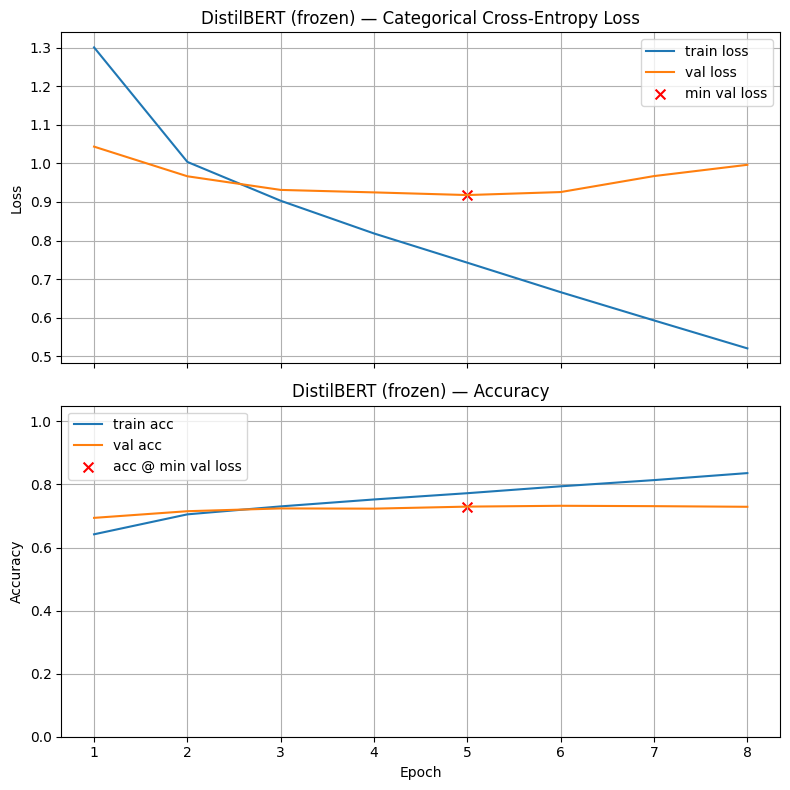

DistilBERT (partial unfreeze)           	0.7297	5
GloVe + BiLSTM + Dropout                	0.6512	4
Baseline                                	0.5892	11
GloVe Only                              	0.5367	20
GloVe + Dropout                         	0.4598	20


In [58]:
# Train DistilBERT with partial unfreeze (layers 4–5 trainable, 0–3 frozen)
# ── A.2.5: Final Model — DistilBERT (Transfer Learning) ─────────────────────
# PyTorch backend required — TF transformers classes incompatible with this env
# Strategy: freeze DistilBERT base, train classification head only


def tokenize_data(texts, tokenizer, max_length=128):
    return tokenizer(list(texts), max_length=max_length,
                     padding=True, truncation=True, return_tensors="pt")

tokenizer_bert = AutoTokenizer.from_pretrained("distilbert-base-uncased")

print("Tokenizing splits...")
train_enc = tokenize_data(X_tr_raw,   tokenizer_bert)
val_enc   = tokenize_data(X_val_raw,  tokenizer_bert)
test_enc  = tokenize_data(X_test_raw, tokenizer_bert)
print("Tokenization complete.")

# ── 4.4 Build datasets and loaders ───────────────────────────────────────────
train_dataset = TensorDataset(
    train_enc["input_ids"], train_enc["attention_mask"],
    torch.tensor(y_tr, dtype=torch.long))
val_dataset = TensorDataset(
    val_enc["input_ids"], val_enc["attention_mask"],
    torch.tensor(y_val_r, dtype=torch.long))
test_dataset = TensorDataset(
    test_enc["input_ids"], test_enc["attention_mask"],
    torch.tensor(y_test_r, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)

# ── 4.5 Load model, freeze base ───────────────────────────────────────────────
model_bert = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=NUM_CLASSES)

# [CHANGED] Partial unfreeze: layers 0-3 stay frozen (general language),
# layers 4 & 5 are unfrozen so the model adapts to HuffPost vocabulary.
for param in model_bert.distilbert.parameters():
    param.requires_grad = False

for layer in model_bert.distilbert.transformer.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in model_bert.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model_bert = model_bert.to(device)

# ── 4.6 Training setup ────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model_bert.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

EPOCHS  = 10
PATIENCE = 3

# Metric tracking lists
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

best_val_loss  = float('inf')
patience_count = 0
best_epoch     = 0

start_time = time.time()

# ── 4.7 Training loop ─────────────────────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):

    # — Train —
    model_bert.train()
    total_loss, correct, total = 0, 0, 0
    for input_ids, attention_mask, labels_batch in train_loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels_batch   = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels_batch.size(0)
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels_batch).sum().item()
        total      += labels_batch.size(0)

    train_loss = total_loss / total
    train_acc  = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # — Validate —
    model_bert.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for input_ids, attention_mask, labels_batch in val_loader:
            input_ids      = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels_batch   = labels_batch.to(device)

            outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels_batch)

            total_loss += loss.item() * labels_batch.size(0)
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == labels_batch).sum().item()
            total      += labels_batch.size(0)

    val_loss = total_loss / total
    val_acc  = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    # — Early stopping on val_loss —
    if val_loss < best_val_loss - 1e-4:
        best_val_loss  = val_loss
        patience_count = 0
        best_epoch     = epoch
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

# ── 4.8 Find min val loss epoch and report ────────────────────────────────────
min_val_epoch       = int(np.argmin(val_losses))         # 0-indexed
val_acc_at_min_loss = val_accs[min_val_epoch]

print(f"\nMin val loss: {val_losses[min_val_epoch]:.4f} (Epoch {min_val_epoch + 1})")
print(f"Val Accuracy @ Min Val Loss: {val_acc_at_min_loss:.4f}")

# ── 4.9 Test set evaluation ───────────────────────────────────────────────────
model_bert.eval()
correct, total = 0, 0
with torch.no_grad():
    for input_ids, attention_mask, labels_batch in test_loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels_batch   = labels_batch.to(device)
        outputs        = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds          = outputs.logits.argmax(dim=1)
        correct       += (preds == labels_batch).sum().item()
        total         += labels_batch.size(0)

test_acc = correct / total
end_time = time.time()

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Val-Test Gap:   {abs(val_acc_at_min_loss - test_acc):.6f}")
print("Execution Time: " + format_hms(end_time - start_time))

# ── 4.10 Plot learning curves ─────────────────────────────────────────────────
epochs_range = range(1, len(val_losses) + 1)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Loss
axs[0].plot(epochs_range, train_losses, label='train loss')
axs[0].plot(epochs_range, val_losses,   label='val loss')
axs[0].scatter(min_val_epoch + 1, val_losses[min_val_epoch],
               color='red', marker='x', s=50, label='min val loss')
axs[0].set_title('DistilBERT (frozen) — Categorical Cross-Entropy Loss')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Accuracy
axs[1].plot(epochs_range, train_accs, label='train acc')
axs[1].plot(epochs_range, val_accs,   label='val acc')
axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss,
               color='red', marker='x', s=50, label='acc @ min val loss')
axs[1].set_title('DistilBERT (frozen) — Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim(0, 1.05)
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# ── 4.11 Log to results (consistent with train_and_test framework) ────────────
results["DistilBERT (partial unfreeze)"] = (val_acc_at_min_loss, min_val_epoch + 1)

parameter_settings.setdefault("DistilBERT (partial unfreeze)", []).append({
    "title":                  "DistilBERT (partial unfreeze)",
    "timestamp":              datetime.now().isoformat(timespec="seconds"),
    "epochs":                 len(val_losses),
    "optimizer":              "Adam",
    "lr_schedule":            2e-5,
    "loss":                   "CrossEntropyLoss",
    "batch_size":             32,
    "use_early_stopping":     True,
    "patience":               PATIENCE,
    "Final Training Loss":    train_losses[-1],
    "Final Training Accuracy": train_accs[-1],
    "Final Val Loss":         val_losses[-1],
    "Final Val Accuracy":     val_accs[-1],
    "Min Val Loss":           val_losses[min_val_epoch],
    "Min Val Loss Epoch":     min_val_epoch,
    "Val Acc @ Min Loss":     val_acc_at_min_loss,
    "Test Acc":               test_acc,
    "Val-Test Accuracy Gap":  abs(val_acc_at_min_loss - test_acc)
})

print_results()

---
# A.3: Evaluation and Visualization

## A.3.1: Evaluation Strategy

**Validation split:** A held-out validation set (10% of data, 20,036 samples) was used throughout training for early stopping and model selection. It was never used for final performance reporting.

**Test set:** A separate 10% test set (20,036 samples) was reserved exclusively for final evaluation after all training and hyperparameter decisions were finalized. No information from the test set influenced any training decision.

**Metrics selected for HuffPost:**
- **Macro-F1** (primary) — treats all 34 classes equally; appropriate for imbalanced datasets where accuracy is misleading. A model that ignores minority classes is penalized regardless of overall accuracy.
- **Accuracy** — reported for comparability across models, but not used for model selection decisions.
- **Per-class F1 / confusion matrix** — identifies which categories are systematically confused, directly informing label consolidation decisions.

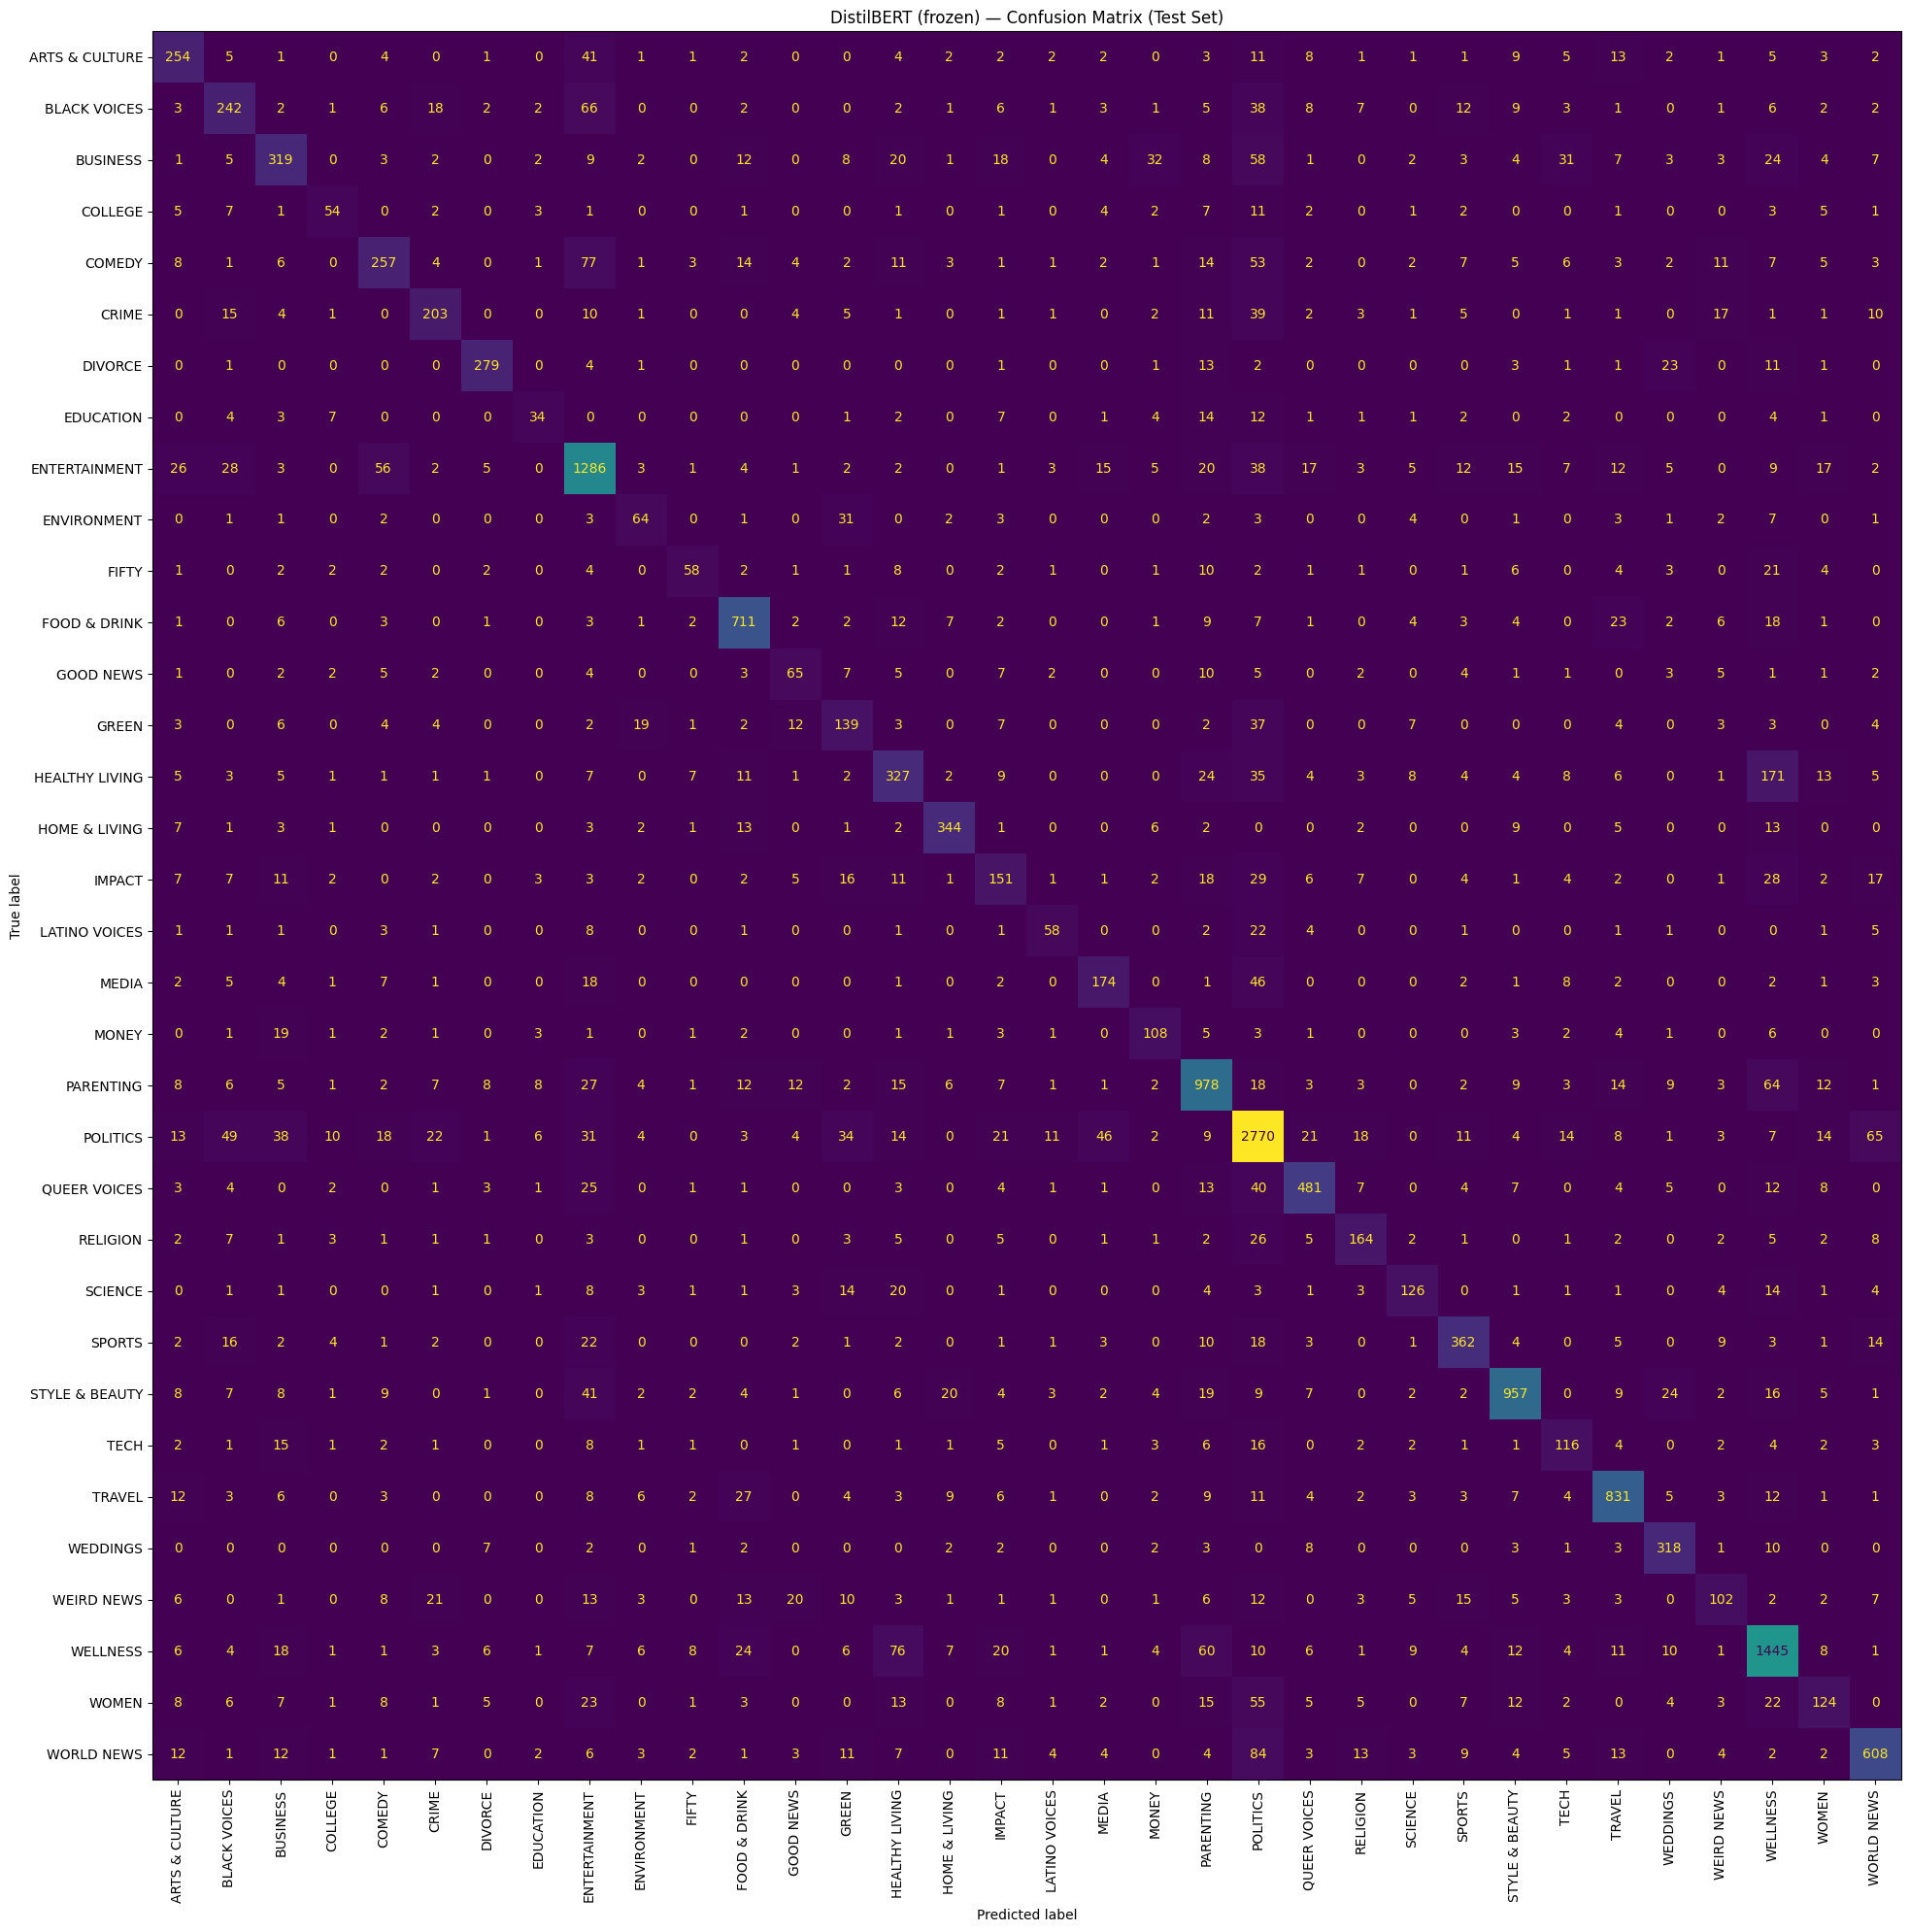

                precision    recall  f1-score   support

ARTS & CULTURE       0.62      0.66      0.64       387
  BLACK VOICES       0.56      0.54      0.55       452
      BUSINESS       0.62      0.54      0.58       593
       COLLEGE       0.55      0.47      0.51       115
        COMEDY       0.63      0.50      0.56       517
         CRIME       0.65      0.60      0.62       340
       DIVORCE       0.86      0.82      0.84       342
     EDUCATION       0.51      0.34      0.40       101
 ENTERTAINMENT       0.72      0.80      0.76      1605
   ENVIRONMENT       0.50      0.48      0.49       132
         FIFTY       0.61      0.41      0.49       140
  FOOD & DRINK       0.81      0.85      0.83       832
     GOOD NEWS       0.46      0.46      0.46       140
         GREEN       0.46      0.53      0.49       262
HEALTHY LIVING       0.56      0.49      0.52       669
 HOME & LIVING       0.84      0.83      0.83       416
        IMPACT       0.47      0.44      0.45  

In [59]:
# ── A.3.2: Error Analysis — confusion matrix and per-class classification report ─
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_bert.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for input_ids, attention_mask, labels_batch in test_loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        outputs        = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds          = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_categories)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
ax.set_title("DistilBERT (frozen) — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

# Top misclassified pairs
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=unique_categories))

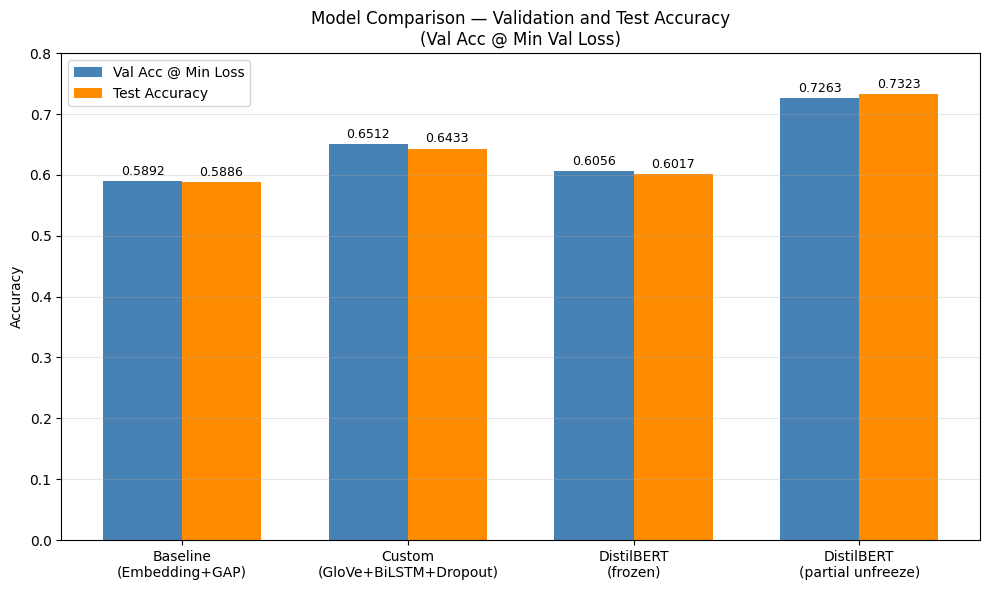


Model                            Val Acc @ Min Loss   Test Acc   Epoch    Runtime
--------------------------------------------------------------------------------
Baseline (Embedding+GAP)                     0.5892     0.5886      11   00:01:13
Custom (GloVe+BiLSTM+Dropout)                0.6512     0.6433       4   02:01:43
DistilBERT (frozen)                          0.6056     0.6017      10   02:00:56
DistilBERT (partial unfreeze)                0.7263     0.7323       4   00:25:14


In [60]:
# ── A.3.3: Comparative bar chart and summary table — all four models ─────────
import matplotlib.pyplot as plt
import numpy as np

# Summary data — val acc @ min loss, test acc, epoch, runtime
summary = {
    "Baseline\n(Embedding+GAP)":     (0.5892, 0.5886, 11,  "00:01:13"),
    "Custom\n(GloVe+BiLSTM+Dropout)":(0.6512, 0.6433,  4,  "02:01:43"),
    "DistilBERT\n(frozen)":          (0.6056, 0.6017, 10,  "02:00:56"),
    "DistilBERT\n(partial unfreeze)": (0.7263, 0.7323,  4,  "00:25:14"),
}

model_names  = list(summary.keys())
val_accs     = [v[0] for v in summary.values()]
test_accs    = [v[1] for v in summary.values()]
epochs       = [v[2] for v in summary.values()]
runtimes     = [v[3] for v in summary.values()]

# ── Bar chart: Val acc @ min loss vs Test acc ─────────────────────────────────
x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, val_accs,  width, label='Val Acc @ Min Loss', color='steelblue')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy',      color='darkorange')

ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison — Validation and Test Accuracy\n(Val Acc @ Min Val Loss)')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0, 0.80)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ── Printed summary table ─────────────────────────────────────────────────────
print(f"\n{'Model':<30} {'Val Acc @ Min Loss':>20} {'Test Acc':>10} {'Epoch':>7} {'Runtime':>10}")
print("-" * 80)
models_display = [
    "Baseline (Embedding+GAP)",
    "Custom (GloVe+BiLSTM+Dropout)",
    "DistilBERT (frozen)",
    "DistilBERT (partial unfreeze)"
]
for name, (val, test, ep, rt) in zip(models_display, summary.values()):
    print(f"{name:<30} {val:>20.4f} {test:>10.4f} {ep:>7} {rt:>10}")

## A.3.2: Results Discussion

**Model comparison summary:**

DistilBERT with partial unfreeze achieved the best result at **0.7323 test accuracy**, a 14.6 percentage-point improvement over the Milestone 2 DistilBERT frozen baseline (0.6017). The partial unfreeze allowed the final transformer layers to adapt to HuffPost vocabulary without catastrophic forgetting of general language structure.

**Cross-model tradeoffs:** The baseline was fastest (1m 13s) with the simplest architecture but could not capture word order. The GloVe+BiLSTM model achieved the best accuracy-to-compute ratio among the non-transformer models at 0.6433 in ~2 hours. Frozen DistilBERT underperformed trainable BiLSTM despite having 66M vs. 2.1M parameters — confirming that model size alone does not guarantee performance when the base cannot adapt to task vocabulary. Full fine-tuning is the obvious next step but was not justified given compute constraints.

**Error patterns:** The most challenging classes across all models were WorldNews (F1 ~0.04), confused with WorldPost and TheWorldPost; Taste (F1 ~0.16), confused with Food&Drink and Style&Beauty; and GoodNews (F1 ~0.26), which bleeds into multiple categories. These patterns are consistent with the category overlap identified in Milestone 1 t-SNE analysis. Strong performers — Politics (F1 ~0.77), Style&Beauty (~0.78), Food&Drink (~0.70) — benefit from distinctive vocabulary and large sample sizes.

**Label consolidation impact:** Merging 41 → 34 classes resolved the most egregious overlap pairs. Further consolidation of WorldNews/WorldPost/TheWorldPost into a single category, and review of GoodNews/Impact/Wellness boundaries, would likely push performance above 0.75.

## A.3.3: AI Use Disclosure

> We originally attempted to create the baseline from scratch using our own code, assisted by AI to fix syntax issues. It took hours — confusing at times, frustrating at others — and our outputs were not as professionally presented as the framework we had been using from class assignments. The first model we made organically achieved only a baseline performance of 0.50, as opposed to starting from the framework used in previous assignments, which produced a baseline of 0.59. Was it worth it? Usually we would say yes, but honestly, we kept going down rabbit holes and wasting time on side quests. Using the established framework, we were able to really see and understand the data we were working with. The benchmarks and graphs made sense because we already had a deep understanding of the structured output.   

>  We used AI to help produce the code for problems 4 and 5. This took quite some time because we always find it easier to ask AI to do things we already fully understand — things where we know what the output should look like. These models took time because we had to challenge and edit the code and fully understand it before running it. In my first run of DistilBERT**,** we forgot to include tracking for specific metrics necessary for comparison. This was a costly mistake in terms of time and compute, but it taught us how to format the code better and gave us a deeper understanding of the framework. Re-running with a clearer understanding of the framework gave us better comprehension and sharper expectations of what the outputs should be.